In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv(
    "../data/train_data.txt",
    sep=" ::: ",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"],
    engine="python"
)

df.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [3]:
print("Shape:", df.shape)

df.info()

df.isnull().sum()

Shape: (54214, 4)
<class 'pandas.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           54214 non-null  int64
 1   TITLE        54214 non-null  str  
 2   GENRE        54214 non-null  str  
 3   DESCRIPTION  54214 non-null  str  
dtypes: int64(1), str(3)
memory usage: 34.4 MB


ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64

In [4]:
df["GENRE"].value_counts()

GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64

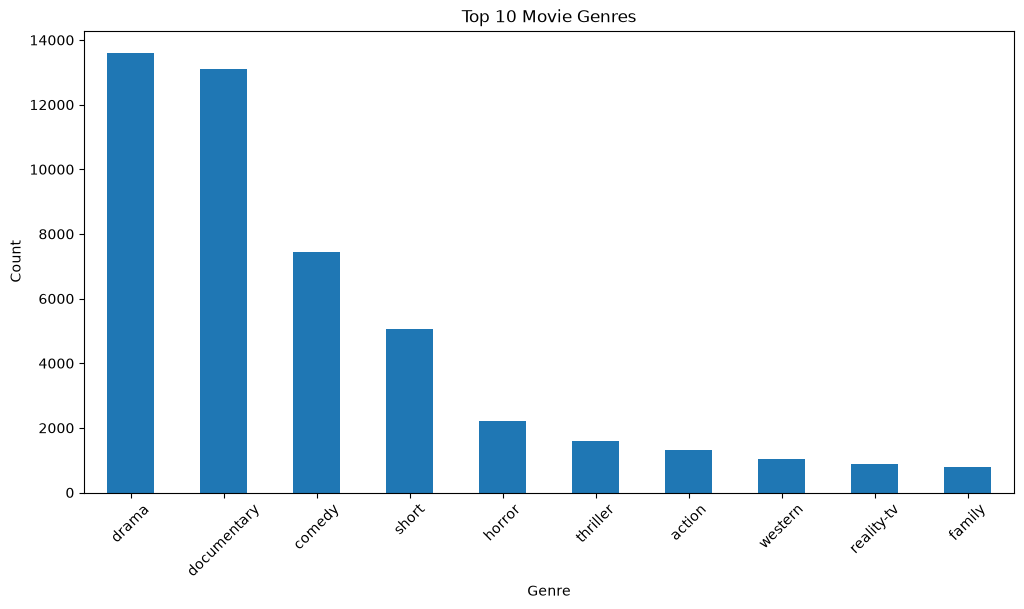

In [5]:
plt.figure(figsize=(12,6))

df["GENRE"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [6]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_description'] = df['DESCRIPTION'].apply(clean_text)

df[['DESCRIPTION', 'clean_description']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pranj\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,DESCRIPTION,clean_description
0,Listening in to a conversation between his doc...,listening conversation doctor parents yearold ...
1,A brother and sister with a past incestuous re...,brother sister past incestuous relationship cu...
2,As the bus empties the students for their fiel...,bus empties students field trip museum natural...
3,To help their unemployed father make ends meet...,help unemployed father make ends meet edith tw...
4,The film's title refers not only to the un-rec...,films title refers unrecovered bodies ground z...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)

X = tfidf.fit_transform(df['clean_description'])

y = df['GENRE']

In [8]:
print(X.shape)

(54214, 10000)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(43371, 10000)
(10843, 10000)


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [11]:
y_pred = model.predict(X_test)


In [12]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.5837867748778014
              precision    recall  f1-score   support

      action       0.52      0.24      0.33       263
       adult       0.81      0.20      0.32       112
   adventure       0.46      0.14      0.21       139
   animation       0.50      0.05      0.09       104
   biography       0.00      0.00      0.00        61
      comedy       0.52      0.60      0.56      1443
       crime       0.25      0.01      0.02       107
 documentary       0.67      0.85      0.75      2659
       drama       0.54      0.79      0.64      2697
      family       0.50      0.07      0.13       150
     fantasy       0.00      0.00      0.00        74
   game-show       0.94      0.40      0.56        40
     history       0.00      0.00      0.00        45
      horror       0.65      0.58      0.61       431
       music       0.64      0.47      0.54       144
     musical       1.00      0.02      0.04        50
     mystery       0.00      0.00      0.00        5

d:\Movie-Genre-Classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Movie-Genre-Classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Movie-Genre-Classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [20]:
import joblib

joblib.dump(model, "../models/genre_model.pkl")
joblib.dump(tfidf, "../models/tfidf.pkl")

['../models/tfidf.pkl']

In [21]:
import joblib

joblib.dump(model, "../models/genre_model.pkl")

['../models/genre_model.pkl']

In [14]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.5704140920409481
              precision    recall  f1-score   support

      action       0.43      0.33      0.37       263
       adult       0.75      0.45      0.56       112
   adventure       0.41      0.27      0.33       139
   animation       0.33      0.13      0.19       104
   biography       0.00      0.00      0.00        61
      comedy       0.51      0.57      0.54      1443
       crime       0.19      0.06      0.09       107
 documentary       0.70      0.81      0.75      2659
       drama       0.57      0.69      0.62      2697
      family       0.30      0.16      0.21       150
     fantasy       0.12      0.03      0.04        74
   game-show       0.79      0.68      0.73        40
     history       0.00      0.00      0.00        45
      horror       0.61      0.65      0.63       431
       music       0.56      0.56      0.56       144
     musical       0.25      0.04      0.07        50
     mystery       0.19      0.05      0.08     

<Figure size 1500x1500 with 0 Axes>

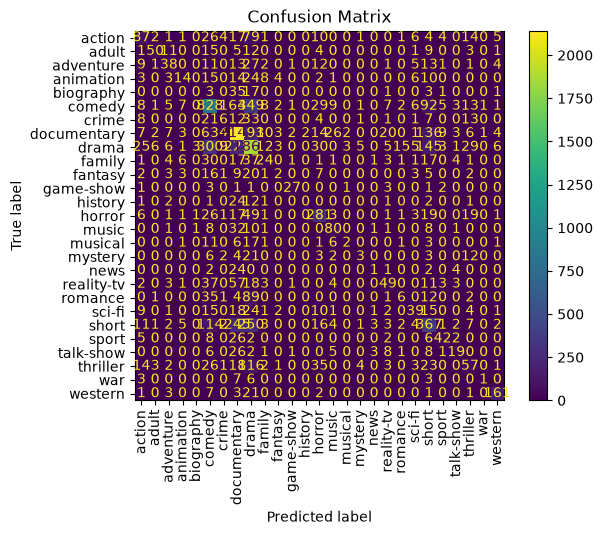

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    xticks_rotation=90
)

plt.title("Confusion Matrix")
plt.show()

In [17]:
import joblib

joblib.dump(svm_model, "../models/genre_model.pkl")
joblib.dump(tfidf, "../models/tfidf.pkl")

['../models/tfidf.pkl']

In [18]:
text = ["A detective investigates a mysterious murder in New York city."]

clean_text_input = clean_text(text[0])

vector = tfidf.transform([clean_text_input])

prediction = svm_model.predict(vector)

print("Predicted Genre:", prediction[0])

Predicted Genre: thriller


In [19]:
import joblib

joblib.dump(model, "../models/genre_model.pkl")

['../models/genre_model.pkl']